# 04 | Model Development
**Project:** Predictive Analytics and AI-Driven Nutrition Solution for Early Detection and Management of Type 2 Diabetes

**Notebook:** 4 of 6

**Purpose:** This notebook focuses on preparing the feature-engineered dataset for machine learning.

The preprocessing steps include:
- Encoding categorical variables
- Splitting the dataset into training and testing sets
- Scaling numerical features
- Applying SMOTE to address class imbalance

After preprocessing, three machine learning models are trained and evaluated:
- Logistic Regression
- Random Forest
- XGBoost
The goal is to compare model performance and identify strong candidates for further optimisation.

**Input:** `data/processed/glucose_spike_features.csv`

**Output:** Trained models and initial performance metrics.
These results will be carried forward to the final notebook for hyperparameter tuning and detailed model evaluation.


**Next notebook:** `05_model_evaluation.ipynb`

---

## 0. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.dpi"]   = 120
plt.rcParams["savefig.bbox"] = "tight"

SPIKE_COLORS = {0: "#4CAF50", 1: "#E53935"}
ACCENT       = "#2196F3"
RANDOM_STATE = 42

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("Libraries loaded.")

Libraries loaded.


---
## 1. Load Feature-Engineered Dataset

In [2]:
df_clean = pd.read_csv("data/processed/glucose_spike_features.csv")
print(f"Loaded: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
df_clean.head()

Loaded: 5,000 rows, 45 columns


,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,...,sugar_carb_ratio,fat_carb_ratio,total_macros,carb_macro_pct,protein_macro_pct,fat_macro_pct,smokes,drinks,lifestyle_risk_score,high_lifestyle_risk
0,63,Male,25.318753,Type 2,Snack,206.078625,96.988928,81.332092,19.881550,27.005984,...,0.131047,0.394665,384.399646,53.610514,25.231274,21.158212,1,0,3.553656,1
1,43,Female,29.887205,Type 1,Snack,110.277131,41.988332,65.323781,9.660801,74.298628,...,0.673745,0.592360,217.589244,50.681334,19.297062,30.021604,0,0,1.451358,0
2,65,Female,21.831540,Type 1,Breakfast,88.692079,74.612428,26.828247,26.701083,48.146920,...,0.542855,0.302488,190.132754,46.647448,39.242280,14.110271,0,0,2.064793,0
3,56,Male,26.610861,Type 2,Dinner,168.193534,70.944312,58.451133,23.006694,56.527922,...,0.336089,0.347523,297.588979,56.518737,23.839697,19.641565,0,0,1.752899,0
4,58,Male,26.649132,Type 2,Dinner,93.580856,74.851625,14.576802,19.789018,0.000000,...,0.000000,0.155767,183.009283,51.134486,40.900453,7.965061,1,0,2.710230,0


## 7. Separate Target Variable from Predictors

In [3]:
X = df_clean.drop(columns=["glucose_spike"])   # everything except what we are predicting
y = df_clean["glucose_spike"]                  # the thing we are trying to predict

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts().to_string()}")

Feature matrix X : (5000, 44)
Target vector  y : (5000,)

Target distribution:
glucose_spike
0    2683
1    2317


## 8. Encode Categorical Variables

Machine learning algorithms require numerical input. We apply Label Encoding to high-cardinality features and One-Hot Encoding to low-cardinality nominal categories, avoiding the dummy variable trap.

In [4]:
# need to catch "category" dtype too — pd.cut() creates category columns, not object
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}): {cat_cols}")

HIGH_CARD = 10
le_store  = {}

# anything with more than 10 unique values gets label encoded
# anything with 10 or fewer gets one-hot encoded
high_card = [c for c in cat_cols if X[c].nunique() > HIGH_CARD]
low_card  = [c for c in cat_cols if X[c].nunique() <= HIGH_CARD]

print(f"\nHigh cardinality (LabelEncode)  : {high_card}")
print(f"Low  cardinality (OneHotEncode) : {low_card}")

for col in high_card:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_store[col] = le   # save the encoder in case we need to inverse_transform later

if low_card:
    # drop_first=True removes one dummy per group to avoid multicollinearity
    X = pd.get_dummies(X, columns=low_card, drop_first=True, dtype=int)

print(f"\nX shape after encoding: {X.shape}")

Categorical columns to encode (7): ['gender', 'diabetes_type', 'meal_time', 'smoking_status', 'alcohol_consumption', 'bmi_category', 'age_group']

High cardinality (LabelEncode)  : []
Low  cardinality (OneHotEncode) : ['gender', 'diabetes_type', 'meal_time', 'smoking_status', 'alcohol_consumption', 'bmi_category', 'age_group']

X shape after encoding: (5000, 50)


## 8.1 Verify Encoded Features

In [5]:
remaining_cat = X.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns remaining : {remaining_cat if remaining_cat else 'None'}")
print(f"X shape after encoding        : {X.shape}")
X.head()

Categorical columns remaining : None
X shape after encoding        : (5000, 50)


,age,bmi,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,portion_size,water_intake,...,meal_time_Lunch,meal_time_Snack,smoking_status_Yes,alcohol_consumption_Yes,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,age_group_Middle-Aged (51-65),age_group_Seniors (66+),age_group_Young Adults (18-35)
0,63,25.318753,206.078625,96.988928,81.332092,19.881550,27.005984,67.508785,100.000000,241.797963,...,0,1,1,0,0,1,0,1,0,0
1,43,29.887205,110.277131,41.988332,65.323781,9.660801,74.298628,72.596360,482.378834,229.778879,...,0,1,0,0,0,1,0,0,0,0
2,65,21.831540,88.692079,74.612428,26.828247,26.701083,48.146920,52.777497,564.170251,203.040939,...,0,0,0,0,0,0,0,1,0,0
3,56,26.610861,168.193534,70.944312,58.451133,23.006694,56.527922,76.054964,400.899454,370.953210,...,0,0,0,0,0,1,0,1,0,0
4,58,26.649132,93.580856,74.851625,14.576802,19.789018,0.000000,62.084038,521.332119,572.649114,...,0,0,1,0,0,1,0,1,0,0


## 9. Train-Test Split

Stratified 80/20 split preserves the no spike/spike class ratio in both training and test sets.

In [6]:
# stratify=y ensures the spike rate is roughly the same in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set : {X_train.shape[0]:>10,} rows (80%)")
print(f"Test set     : {X_test.shape[0]:>10,} rows (20%)")
print(f"\nTraining target distribution:\n{y_train.value_counts().to_string()}")
print(f"\nTest target distribution:\n{y_test.value_counts().to_string()}")

Training set :      4,000 rows (80%)
Test set     :      1,000 rows (20%)

Training target distribution:
glucose_spike
0    2146
1    1854

Test target distribution:
glucose_spike
0    537
1    463


## 10. Feature Scaling with StandardScaler

Distance-based models (Logistic Regression) are sensitive to feature magnitude. **Critical:** The scaler is fitted ONLY on X_train to prevent data leakage.

In [7]:
# fit on train dataset only 
# leak into the scaler and give us an overly optimistic evaluation
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
                               columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),
                               columns=X_test.columns, index=X_test.index)

print("StandardScaler applied.")
print(f"X_train mean (should be ~0) : {X_train_scaled.mean().mean():.6f}")
print(f"X_train std  (should be ~1) : {X_train_scaled.std().mean():.6f}")
print(f"Shapes - Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

StandardScaler applied.
X_train mean (should be ~0) : -0.000000
X_train std  (should be ~1) : 0.980123
Shapes - Train: (4000, 50) | Test: (1000, 50)


## 11. Handle Class Imbalance Using SMOTE

SMOTE generates synthetic minority-class (spike) samples by interpolating between existing spike observations. Applied ONLY to the training set to avoid contaminating test evaluation.

In [8]:
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts().to_string())

# k_neighbors=5 is the default each synthetic sample is generated from
# the 5 nearest neighbours of a real spike sample
smote = SMOTE(sampling_strategy="auto", k_neighbors=5, random_state=RANDOM_STATE)

print("\nApplying SMOTE...")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts().to_string())
print(f"\nResampled training shape: {X_train_resampled.shape}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in [
    (axes[0], y_train,           "Before SMOTE"),
    (axes[1], y_train_resampled, "After SMOTE")
]:
    vc = pd.Series(data).value_counts()
    ax.bar(["No Spike", "Spike"], vc.values, color=["#4CAF50", "#E53935"], edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel("Count")
    for p, v in zip(ax.patches, vc.values):
        ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.01 * vc.max(),
                f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

Class distribution BEFORE SMOTE:
glucose_spike
0    2146
1    1854

Applying SMOTE...

Class distribution AFTER SMOTE:
glucose_spike
0    2146
1    2146

Resampled training shape: (4292, 50)


KeyboardInterrupt: 

## 12. Baseline Model: Logistic Regression

Logistic Regression is the baseline model we would be using. It provides an interpretable probability-calibrated baseline and it is efficient on large datasets.

Training Logistic Regression...

Logistic Regression Results:
  Accuracy    : 0.7690
  Precision   : 0.7311
  Recall      : 0.7927
  F1-Score    : 0.7606
  ROC-AUC     : 0.8557

Classification Report:
              precision    recall  f1-score   support

    No Spike       0.81      0.75      0.78       537
       Spike       0.73      0.79      0.76       463

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



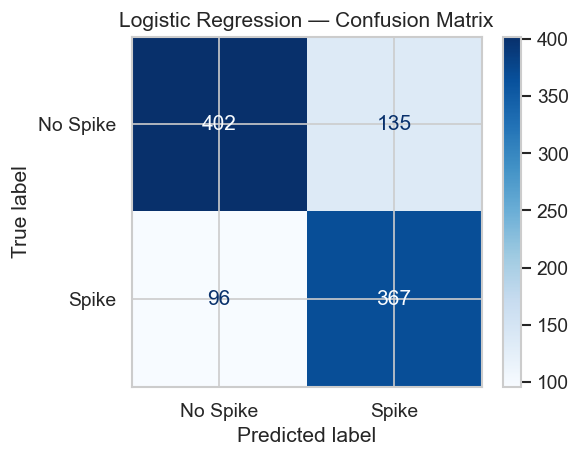

In [ ]:
# saga solver supports both l1 and l2 penalty and handles large datasets well
# class_weight="balanced" adds an extra safety net on top of SMOTE
print("Training Logistic Regression...")
lr_model = LogisticRegression(C=1.0, solver="saga", max_iter=500,
                               class_weight="balanced",
                               random_state=RANDOM_STATE, n_jobs=-1)
lr_model.fit(X_train_resampled, y_train_resampled)

lr_pred      = lr_model.predict(X_test_scaled)
lr_pred_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_metrics = {
    "Accuracy" : accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred, zero_division=0),
    "Recall"   : recall_score(y_test, lr_pred, zero_division=0),
    "F1-Score" : f1_score(y_test, lr_pred, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, lr_pred_prob)
}

print("\nLogistic Regression Results:")
for k, v in lr_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=["No Spike", "Spike"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=ax,
    display_labels=["No Spike", "Spike"], cmap="Blues")
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Advanced Model: Random Forest

Training Random Forest...

Random Forest Results:
  Accuracy    : 0.7600
  Precision   : 0.7234
  Recall      : 0.7797
  F1-Score    : 0.7505
  ROC-AUC     : 0.8388

Classification Report:
              precision    recall  f1-score   support

    No Spike       0.80      0.74      0.77       537
       Spike       0.72      0.78      0.75       463

    accuracy                           0.76      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.76      0.76      0.76      1000



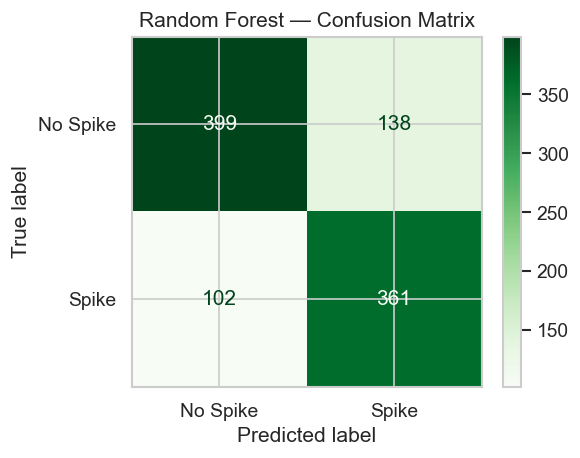

In [ ]:
# 100 trees is a solid starting point which is enough diversity without being too slow
# max_depth=None lets trees grow fully; bagging controls overfitting instead
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_resampled, y_train_resampled)

rf_pred      = rf_model.predict(X_test_scaled)
rf_pred_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_metrics = {
    "Accuracy" : accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall"   : recall_score(y_test, rf_pred, zero_division=0),
    "F1-Score" : f1_score(y_test, rf_pred, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, rf_pred_prob)
}

print("\nRandom Forest Results:")
for k, v in rf_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=["No Spike", "Spike"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=ax,
    display_labels=["No Spike", "Spike"], cmap="Greens")
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

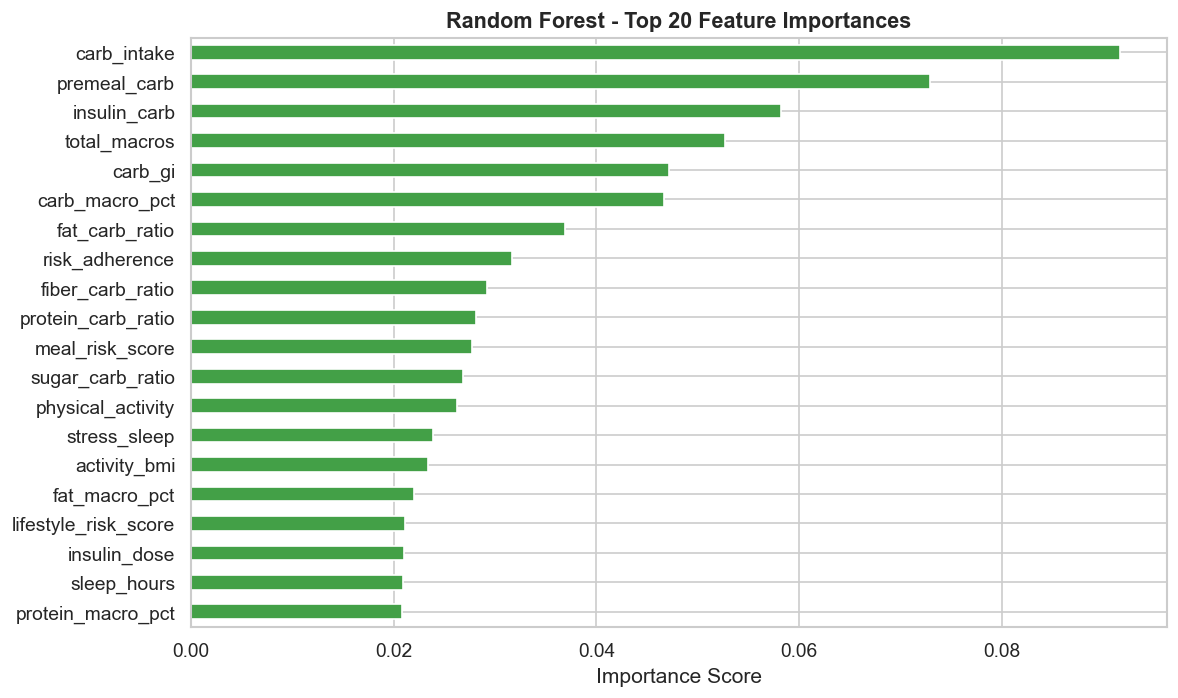


Top 10 most important features:
carb_intake           0.091689
premeal_carb          0.072875
insulin_carb          0.058238
total_macros          0.052684
carb_gi               0.047213
carb_macro_pct        0.046638
fat_carb_ratio        0.036860
risk_adherence        0.031632
fiber_carb_ratio      0.029188
protein_carb_ratio    0.028133


In [ ]:
# feature importance is one of the most useful things about Random Forest 
# it tells us which dietary and lifestyle factors are actually driving the predictions
importances = pd.Series(rf_model.feature_importances_, index=X_train_resampled.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind="barh", ax=ax, color="#43A047", edgecolor="white")
ax.set_title("Random Forest - Top 20 Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(top20.head(10).to_string())

## 14. Advanced Model: XGBoost

Training XGBoost...

XGBoost Results:
  Accuracy    : 0.7550
  Precision   : 0.7198
  Recall      : 0.7711
  F1-Score    : 0.7445
  ROC-AUC     : 0.8386

Classification Report:
              precision    recall  f1-score   support

    No Spike       0.79      0.74      0.76       537
       Spike       0.72      0.77      0.74       463

    accuracy                           0.76      1000
   macro avg       0.75      0.76      0.75      1000
weighted avg       0.76      0.76      0.76      1000



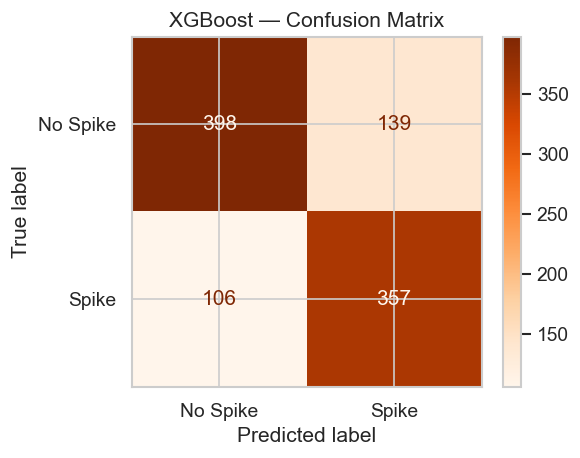

In [ ]:
# XGBoost builds trees sequentially, each one fixing the errors of the last
# subsample and colsample_bytree add randomness to reduce overfitting
print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

xgb_pred      = xgb_model.predict(X_test_scaled)
xgb_pred_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_metrics = {
    "Accuracy" : accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred, zero_division=0),
    "Recall"   : recall_score(y_test, xgb_pred, zero_division=0),
    "F1-Score" : f1_score(y_test, xgb_pred, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, xgb_pred_prob)
}

print("\nXGBoost Results:")
for k, v in xgb_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=["No Spike", "Spike"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred, ax=ax,
    display_labels=["No Spike", "Spike"], cmap="Oranges")
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.show()

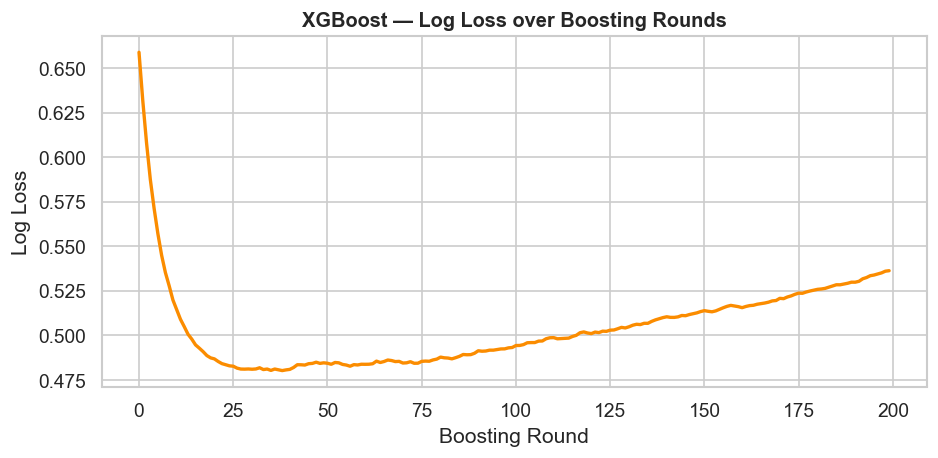

In [ ]:
# the learning curve shows whether the model converged or if more rounds would help
results = xgb_model.evals_result()
epochs  = len(results["validation_0"]["logloss"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(epochs), results["validation_0"]["logloss"], color="#FB8C00", linewidth=2)
ax.set_xlabel("Boosting Round")
ax.set_ylabel("Log Loss")
ax.set_title("XGBoost — Log Loss over Boosting Rounds", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 15. Save Trained Models & Objects for Notebook 5

In [ ]:
import joblib, os
os.makedirs("models", exist_ok=True)

# save all three trained models
joblib.dump(lr_model,  "models/lr_model.pkl")
joblib.dump(rf_model,  "models/rf_model.pkl")
joblib.dump(xgb_model, "models/xgb_model.pkl")

# save the scaler — needed to transform any new data before prediction
joblib.dump(scaler, "models/scaler.pkl")

# save test sets so notebook 5 evaluates on the exact same data
import numpy as np
np.save("models/X_test_scaled.npy",    X_test_scaled.values)
np.save("models/y_test.npy",           y_test.values)
np.save("models/X_train_resampled.npy", X_train_resampled)
np.save("models/y_train_resampled.npy", y_train_resampled)

# save column names so we can rebuild DataFrames in notebook 5
pd.Series(X_test_scaled.columns).to_csv("models/feature_columns.csv", index=False)

print("Saved models and test data:")
print("  models/lr_model.pkl")
print("  models/rf_model.pkl")
print("  models/xgb_model.pkl")
print("  models/scaler.pkl")
print("  models/X_test_scaled.npy")
print("  models/y_test.npy")

Saved models and test data:
  models/lr_model.pkl
  models/rf_model.pkl
  models/xgb_model.pkl
  models/scaler.pkl
  models/X_test_scaled.npy
  models/y_test.npy


In [ ]:
import json

# save the untuned metrics so notebook 5 can show before/after tuning comparison
untuned_metrics = {
    "Logistic Regression": lr_metrics,
    "Random Forest"      : rf_metrics,
    "XGBoost"            : xgb_metrics,
}

with open("models/untuned_metrics.json", "w") as f:
    json.dump(untuned_metrics, f, indent=2)

print("Saved: models/untuned_metrics.json")

Saved: models/untuned_metrics.json
